# TTS Master Curve & Broadband Prony Fit

Apply Time-Temperature Superposition (TTS) to the multi-temperature DMA data to build a master curve spanning many decades of reduced frequency, then fit a broadband Prony series.

Steps:
1. Load full DMA dataset (all 26 temperatures)
2. Load & inspect the provided shift factors $a_T$
3. Build the master curve at reference temperature $T_\text{ref}$
4. Fit WLF and Arrhenius models to $\log a_T$ vs $T$
5. Fit a broadband Prony series to the master curve
6. Validate & compare with single-temperature fit
7. Export broadband Prony parameters

## 0 - Setup & Imports

In [24]:
import sys, os
from pathlib import Path

# Make sure the project root is on the path so we can import src.*
PROJECT_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project modules
from src.io       import load_raw, available_temperatures
from src.tts      import (load_shift_factors, build_master_curve,
                          fit_wlf, fit_arrhenius, master_curve_arrays, wlf, arrhenius)
from src.model    import prony_Gp, prony_Gpp
from src.fit      import fit_prony
from src.validate import compute_metrics, plot_overview
from src.export   import export_csv, export_metrics_json, prony_table, export_abaqus_snippet

%matplotlib inline
print("Setup complete")

Setup complete


## 1 - Load DMA Data & Shift Factors

The dataset provides pre-computed horizontal shift factors $a_T$ for each temperature. The reference temperature is where $\log a_T = 0$.

In [25]:
df_all = load_raw()
print(f"Loaded {len(df_all)} rows across {df_all['temp_C'].nunique()} temperatures")

sf = load_shift_factors()
print(f"\nShift factors (T_ref where log aT ~ 0):")
sf

Loaded 806 rows across 26 temperatures

Shift factors (T_ref where log aT ≈ 0):


,temp_C,aT,log_aT
0,-50,2.448000e+22,22.388811
1,-40,2.262096e+20,20.354511
2,-30,2.052000e+18,18.312177
3,-20,2.705472e+16,16.432243
4,-10,4.896000e+14,14.689841
5,0,1.200845e+13,13.079487
6,10,3.813120e+11,11.581280
7,20,1.537834e+10,10.186909
8,30,7.632000e+08,8.882638
9,40,4.609930e+07,7.663694


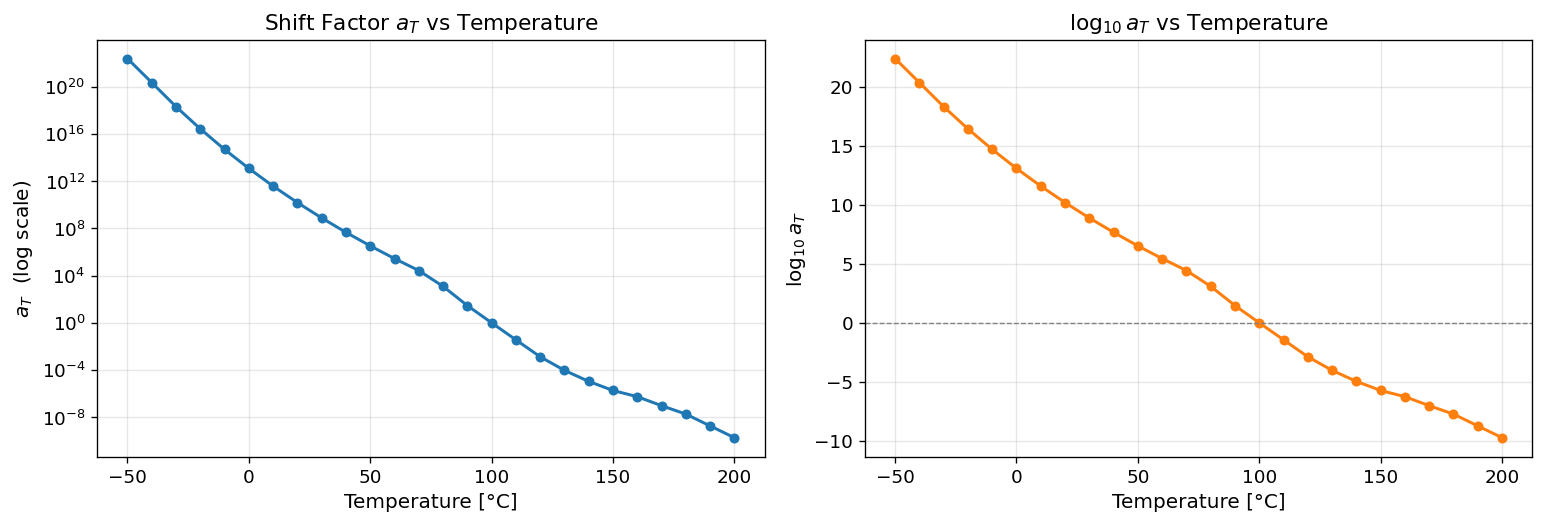

Reference temperature (log aT ≈ 0):  T_ref = 100 °C  (log aT = 0.0000)


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.semilogy(sf["temp_C"], sf["aT"], "o-", color="C0")
ax1.set_xlabel("Temperature [C]"); ax1.set_ylabel("$a_T$  (log scale)")
ax1.set_title("Shift Factor $a_T$ vs Temperature"); ax1.grid(True, alpha=0.3)

ax2.plot(sf["temp_C"], sf["log_aT"], "o-", color="C1")
ax2.axhline(0, color="grey", ls="--", lw=0.8)
ax2.set_xlabel("Temperature [C]"); ax2.set_ylabel("$\\log_{10} a_T$")
ax2.set_title("$\\log_{10} a_T$ vs Temperature"); ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

T_ref_idx = sf["log_aT"].abs().idxmin()
print(f"Reference temperature (log aT ~ 0):  T_ref = {sf.loc[T_ref_idx, 'temp_C']} C  (log aT = {sf.loc[T_ref_idx, 'log_aT']:.4f})")

## 2 - Build the Master Curve

Shift each temperature slice horizontally using $\omega_\text{reduced} = a_T \cdot \omega$ to collapse all data onto a single curve at the reference temperature.

In [ ]:
mc, T_ref = build_master_curve(df_all, sf)

print(f"Master curve at T_ref = {T_ref} C")
print(f"Reduced w range: {mc['omega_reduced'].min():.2e} - {mc['omega_reduced'].max():.2e} rad/s")
print(f"  -> spans {np.log10(mc['omega_reduced'].max()) - np.log10(mc['omega_reduced'].min()):.1f} decades of frequency")
print(f"Total data points: {len(mc)}")

Master curve at T_ref = 100.0 °C
Reduced ω range: 1.84e-11 – 2.45e+24 rad/s
  → spans 35.1 decades of frequency
Total data points: 806


C:\Users\Artis\AppData\Local\Temp\ipykernel_20592\3613588367.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


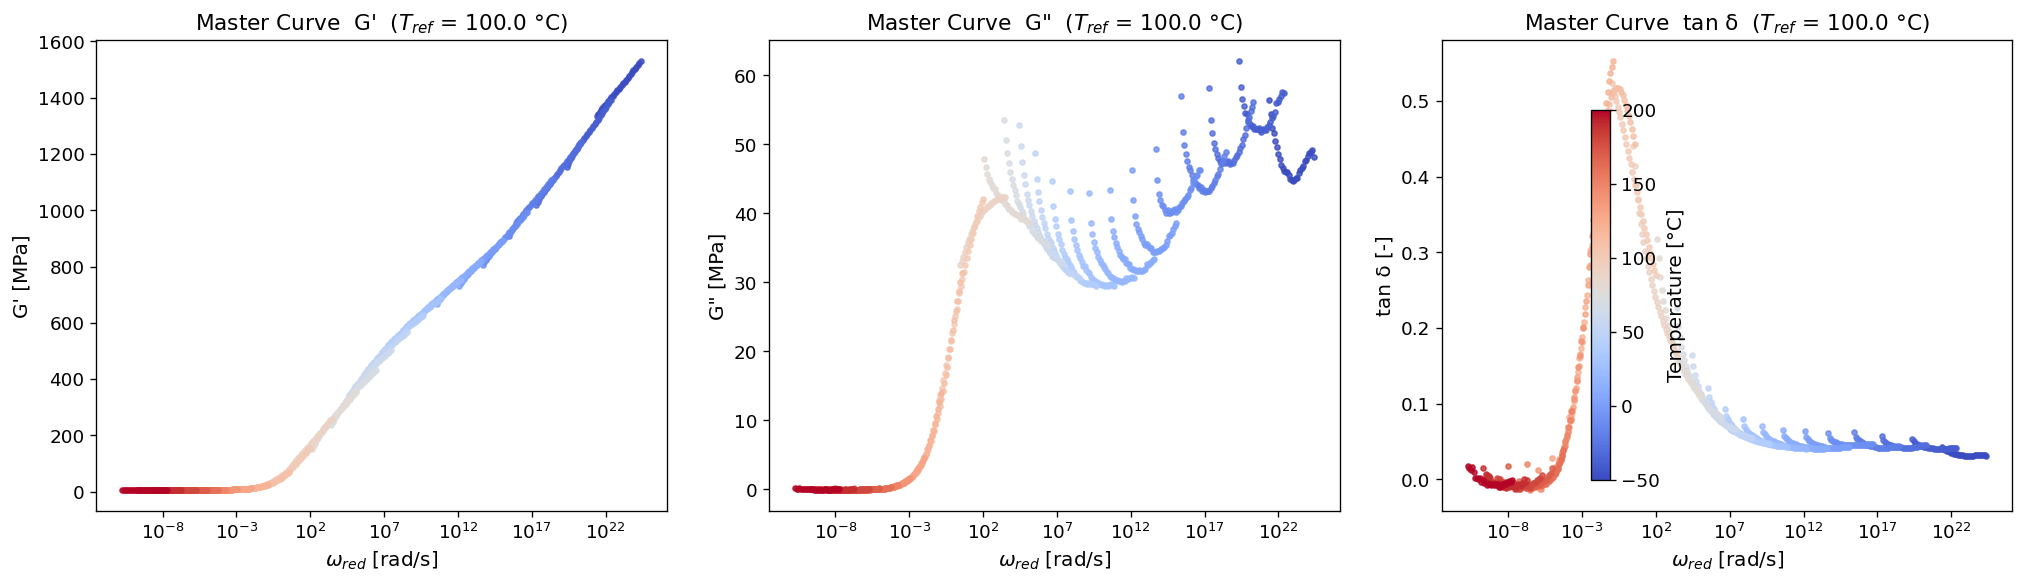

In [ ]:
# Plot the master curve - each temperature in a different colour
temps = sorted(mc["temp_C"].unique())
cmap = plt.cm.coolwarm(np.linspace(0, 1, len(temps)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), layout="constrained")

for i, T in enumerate(temps):
    sub = mc[mc["temp_C"] == T]
    kw = dict(color=cmap[i], markersize=3, alpha=0.8, label=f"{T} C" if i % 4 == 0 else None)
    axes[0].semilogx(sub["omega_reduced"], sub["Gp_MPa"],  "o", **kw)
    axes[1].semilogx(sub["omega_reduced"], sub["Gpp_MPa"], "o", **kw)
    axes[2].semilogx(sub["omega_reduced"], sub["tan_delta"], "o", **kw)

axes[0].set_xlabel("$\\omega_{red}$ [rad/s]"); axes[0].set_ylabel("G' [MPa]")
axes[0].set_title(f"Master Curve G'  ($T_{{ref}}$ = {T_ref} C)")
axes[1].set_xlabel("$\\omega_{red}$ [rad/s]"); axes[1].set_ylabel('G" [MPa]')
axes[1].set_title(f'Master Curve G"  ($T_{{ref}}$ = {T_ref} C)')
axes[2].set_xlabel("$\\omega_{red}$ [rad/s]"); axes[2].set_ylabel("tan d [-]")
axes[2].set_title(f"Master Curve tan d  ($T_{{ref}}$ = {T_ref} C)")

sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=min(temps), vmax=max(temps)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, label="Temperature [C]", shrink=0.8, pad=0.02)

plt.show()

## 3 - Fit WLF & Arrhenius Models to Shift Factors

WLF (Williams-Landel-Ferry):
$$\log_{10} a_T = \frac{-C_1 (T - T_\text{ref})}{C_2 + (T - T_\text{ref})}$$

Arrhenius:
$$\log_{10} a_T = \frac{E_a}{2.303\,R}\left(\frac{1}{T} - \frac{1}{T_\text{ref}}\right)$$

WLF is generally better near $T_g$; Arrhenius works better far above $T_g$.

In [ ]:
temps_arr = sf["temp_C"].values
log_aT    = sf["log_aT"].values

# WLF is only physically valid near Tg.
# Restrict to T_ref +/- 80 C (adjust for your material).
wlf_result = fit_wlf(temps_arr, log_aT, T_ref,
                      T_range=(T_ref - 80, T_ref + 80))
print(f"WLF fit (T_ref = {T_ref} C, "
      f"window = {wlf_result['T_range_used'][0]:.0f}-"
      f"{wlf_result['T_range_used'][1]:.0f} C):")
print(f"  C1 = {wlf_result['C1']:.3f}")
print(f"  C2 = {wlf_result['C2']:.1f} C")
print(f"  Singularity at T = {T_ref - wlf_result['C2']:.1f} C")
print(f"  Residual std (in window) = {wlf_result['residual_std']:.4f}")

# Arrhenius: valid across the full temperature range
arr_result = fit_arrhenius(temps_arr, log_aT, T_ref)
print(f"\nArrhenius fit (T_ref = {T_ref} C, full range):")
print(f"  Ea/R = {arr_result['Ea_over_R_K']:.0f} K")
print(f"  Ea   = {arr_result['Ea_kJ_mol']:.1f} kJ/mol")
print(f"  Residual std = {arr_result['residual_std']:.4f}")

WLF fit (T_ref = 100.0 °C, window = 20–180 °C):
  C1 = 57.736
  C2 = 500.0 °C
  Singularity at T = -400.0 °C
  Residual std (in window) = 0.4927

Arrhenius fit (T_ref = 100.0 °C, full range):
  Ea/R = 30863 K
  Ea   = 256.6 kJ/mol
  Residual std = 1.0275


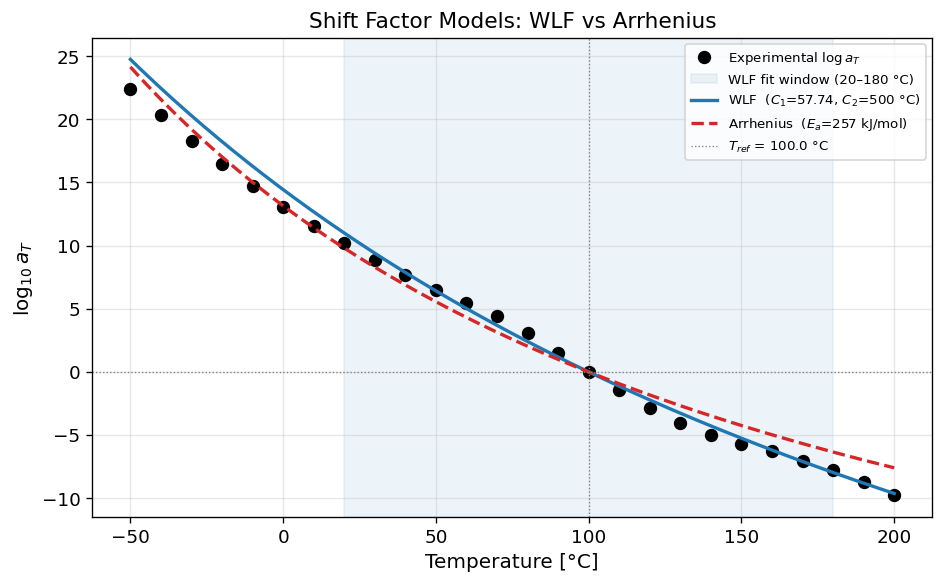

In [30]:
T_smooth = np.linspace(temps_arr.min(), temps_arr.max(), 200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(temps_arr, log_aT, "ko", markersize=7, label="Experimental $\\log a_T$")

# WLF: show fit window as shaded region
T_lo, T_hi = wlf_result["T_range_used"]
ax.axvspan(T_lo, T_hi, alpha=0.08, color="C0", label=f"WLF fit window ({T_lo:.0f}-{T_hi:.0f} C)")
ax.plot(T_smooth, wlf(T_smooth, wlf_result["C1"], wlf_result["C2"], T_ref),
        "-", color="C0", lw=2,
        label=f"WLF  ($C_1$={wlf_result['C1']:.2f}, $C_2$={wlf_result['C2']:.0f} C)")

ax.plot(T_smooth, arrhenius(T_smooth, arr_result["Ea_over_R_K"], T_ref),
        "--", color="C3", lw=2,
        label=f"Arrhenius  ($E_a$={arr_result['Ea_kJ_mol']:.0f} kJ/mol)")
ax.axhline(0, color="grey", ls=":", lw=0.8)
ax.axvline(T_ref, color="grey", ls=":", lw=0.8, label=f"$T_{{ref}}$ = {T_ref} C")
ax.set_xlabel("Temperature [C]"); ax.set_ylabel("$\\log_{10} a_T$")
ax.set_title("Shift Factor Models: WLF vs Arrhenius")
ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4 - Fit Broadband Prony Series to Master Curve

With ~30 decades of reduced frequency available, fit a Prony series that captures the full relaxation spectrum using the collocation method (fixed log-spaced tau, optimise only weights).

In [31]:
from src.fit import fit_prony_collocation
from src.tts import master_curve_arrays

# Extract sorted master-curve arrays
omega_mc, Gp_mc, Gpp_mc, tand_mc = master_curve_arrays(mc)

# Filter data for fitting:
# G'' near zero or negative in plateau regions produces noise that
# dominates the log-space fit. Keep only points above a noise floor.
Gpp_thresh = 0.5  # MPa
good = Gpp_mc > Gpp_thresh
print(f"Data: {len(omega_mc)} total, {good.sum()} with G'' > {Gpp_thresh} MPa (used for fit)\n")

omega_fit = omega_mc[good]
Gp_fit    = Gp_mc[good]
Gpp_fit   = Gpp_mc[good]

# Collocation method: fixed log-spaced tau, optimise only weights.
# This avoids the G'' oscillations that arise when tau positions are free.
result_mc = fit_prony_collocation(omega_fit, Gp_fit, Gpp_fit, N=30, verbose=1)

# Store full-range predictions for plotting
from src.model import prony_Gp, prony_Gpp
result_mc["omega_all"] = omega_mc
result_mc["Gp_all"]    = Gp_mc
result_mc["Gpp_all"]   = Gpp_mc
result_mc["Gp_pred_all"]  = prony_Gp(omega_mc, result_mc["g"], result_mc["tau"], result_mc["G0"])
result_mc["Gpp_pred_all"] = prony_Gpp(omega_mc, result_mc["g"], result_mc["tau"], result_mc["G0"])
N_BROAD = result_mc["N"]

print(f"\n{'='*55}")
print(f"Broadband Prony fit (collocation)  |  N = {N_BROAD} terms")
print(f"T_ref = {T_ref} C")
print(f"G0 (glassy)    = {result_mc['G0']:.2f} MPa")
print(f"G_eq (equil.)  = {result_mc['G_eq']:.2f} MPa")
print(f"sum(g_i)       = {result_mc['g'].sum():.6f}")
print(f"Optimizer cost = {result_mc['opt'].cost:.4e}")
print(f"{'='*55}")

Data: 806 total, 588 with G'' > 0.5 MPa (used for fit)

Collocation: 30 terms, τ range [4.1e-26, 7.5e+04] s, ~1 per 1.0 decades
`ftol` termination condition is satisfied.
Function evaluations 50, initial cost 2.9221e+02, final cost 5.0706e-01, first-order optimality 1.18e-08.

Broadband Prony fit (collocation)  |  N = 30 terms
T_ref = 100.0 °C
G0 (glassy)   = 1586.52 MPa
G_eq (equil.)  = 6.92 MPa
Σ gᵢ          = 0.995636
Optimizer cost = 5.0706e-01


In [32]:
# Prony parameter table
tbl = prony_table(result_mc["g"], result_mc["tau"], result_mc["G0"], result_mc["G_eq"])
tbl

,i,g_i,tau_i_s,G_i_MPa
0,1,1.503851e-21,4.084967e-26,2.385896e-18
1,2,5.602093e-02,4.516795e-25,8.887855e+01
2,3,3.993445e-02,4.994273e-24,6.335696e+01
3,4,4.937054e-02,5.522225e-23,7.832755e+01
4,5,5.244746e-02,6.105988e-22,8.320914e+01
5,6,5.189540e-02,6.751461e-21,8.233330e+01
6,7,4.943490e-02,7.465169e-20,7.842966e+01
7,8,4.462414e-02,8.254323e-19,7.079726e+01
8,9,4.443957e-02,9.126900e-18,7.050444e+01
9,10,4.520843e-02,1.009172e-16,7.172425e+01


## 5 - Validate the Broadband Fit

C:\Users\Artis\AppData\Local\Temp\ipykernel_20592\578585269.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


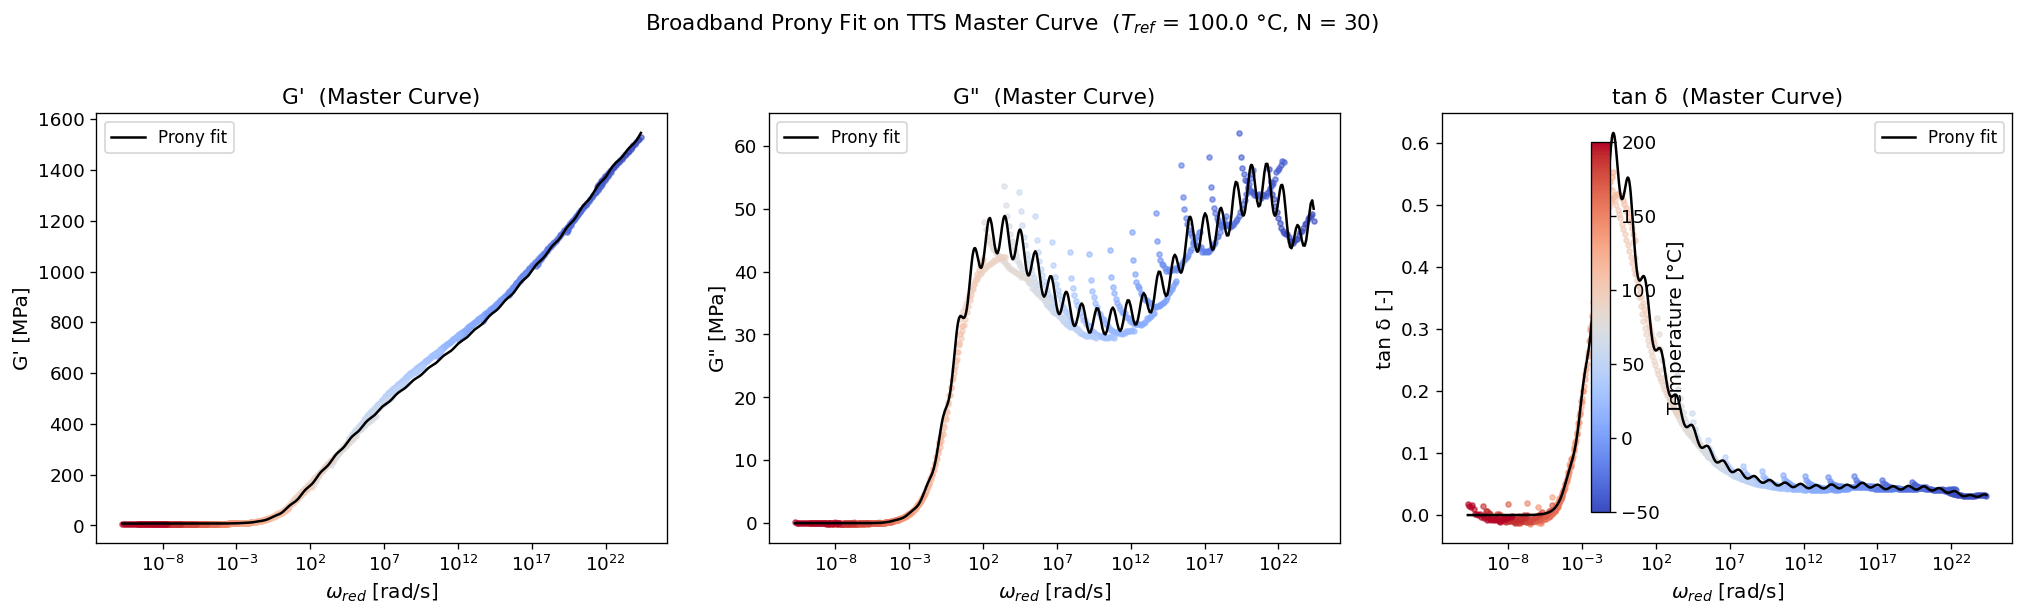

In [33]:
Gp_mc_pred  = result_mc["Gp_pred_all"]
Gpp_mc_pred = result_mc["Gpp_pred_all"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), layout="constrained")

tand_mc_pred = Gpp_mc_pred / np.maximum(Gp_mc_pred, 1e-12)

# Colour data points by temperature
for i, T in enumerate(temps):
    sub = mc[mc["temp_C"] == T].sort_values("omega_reduced")
    kw = dict(color=cmap[i], markersize=3, alpha=0.6)
    axes[0].semilogx(sub["omega_reduced"], sub["Gp_MPa"],  "o", **kw)
    axes[1].semilogx(sub["omega_reduced"], sub["Gpp_MPa"], "o", **kw)
    td = sub["Gpp_MPa"].values / np.maximum(sub["Gp_MPa"].values, 1e-12)
    axes[2].semilogx(sub["omega_reduced"], td, "o", **kw)

order = np.argsort(omega_mc)
axes[0].semilogx(omega_mc[order], Gp_mc_pred[order],  "k-", lw=1.5, label="Prony fit")
axes[1].semilogx(omega_mc[order], Gpp_mc_pred[order], "k-", lw=1.5, label="Prony fit")
axes[2].semilogx(omega_mc[order], tand_mc_pred[order], "k-", lw=1.5, label="Prony fit")

axes[0].set_xlabel("$\\omega_{red}$ [rad/s]"); axes[0].set_ylabel("G' [MPa]")
axes[0].set_title("G'  (Master Curve)"); axes[0].legend()
axes[1].set_xlabel("$\\omega_{red}$ [rad/s]"); axes[1].set_ylabel('G" [MPa]')
axes[1].set_title('G"  (Master Curve)'); axes[1].legend()
axes[2].set_xlabel("$\\omega_{red}$ [rad/s]"); axes[2].set_ylabel("tan d [-]")
axes[2].set_title("tan d  (Master Curve)"); axes[2].legend()

sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=min(temps), vmax=max(temps)))
sm.set_array([])
fig.colorbar(sm, ax=axes, label="Temperature [C]", shrink=0.8, pad=0.02)

fig.suptitle(f"Broadband Prony Fit on TTS Master Curve  ($T_{{ref}}$ = {T_ref} C, N = {N_BROAD})",
             fontsize=13)

from src.validate import FIG_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "master_curve_prony_fit.png", bbox_inches="tight")
plt.show()

In [ ]:
Gp_mc_pred  = result_mc["Gp_pred_all"]
Gpp_mc_pred = result_mc["Gpp_pred_all"]

metrics_mc = compute_metrics(omega_mc, Gp_mc, Gpp_mc, Gp_mc_pred, Gpp_mc_pred)

print("Broadband fit metrics (all data):")
print(f"  G'  RMSE       = {metrics_mc['Gp_RMSE_MPa']:.4f} MPa")
print(f"  G'  rel. error = {metrics_mc['Gp_relErr_pct']:.2f} %")
print(f"  G'' RMSE       = {metrics_mc['Gpp_RMSE_MPa']:.4f} MPa")
print(f"  G'' rel. error = {metrics_mc['Gpp_relErr_pct']:.2f} %")
print(f"  tan d RMSE     = {metrics_mc['tand_RMSE']:.6f}")
print(f"  tan d rel. err = {metrics_mc['tand_relErr_pct']:.2f} %")

metrics_filt = compute_metrics(omega_fit, Gp_fit, Gpp_fit,
                               result_mc["Gp_pred"], result_mc["Gpp_pred"])
print(f"\nFiltered data (G'' > {Gpp_thresh} MPa):")
print(f"  G'  rel. error = {metrics_filt['Gp_relErr_pct']:.2f} %")
print(f"  G'' rel. error = {metrics_filt['Gpp_relErr_pct']:.2f} %")

Broadband fit quality metrics (all data):
  G'  RMSE       = 16.6446 MPa
  G'  rel. error = 3.55 %
  G'' RMSE       = 2.8769 MPa
  G'' rel. error = 38.62 %
  tan δ RMSE     = 0.019669
  tan δ rel. err = 38.87 %

Filtered data (G'' > 0.5 MPa) metrics:
  G'  rel. error = 3.24 %
  G'' rel. error = 6.85 %


## 6 - Relaxation Spectrum

Discrete relaxation spectrum showing where the relaxation times are distributed.

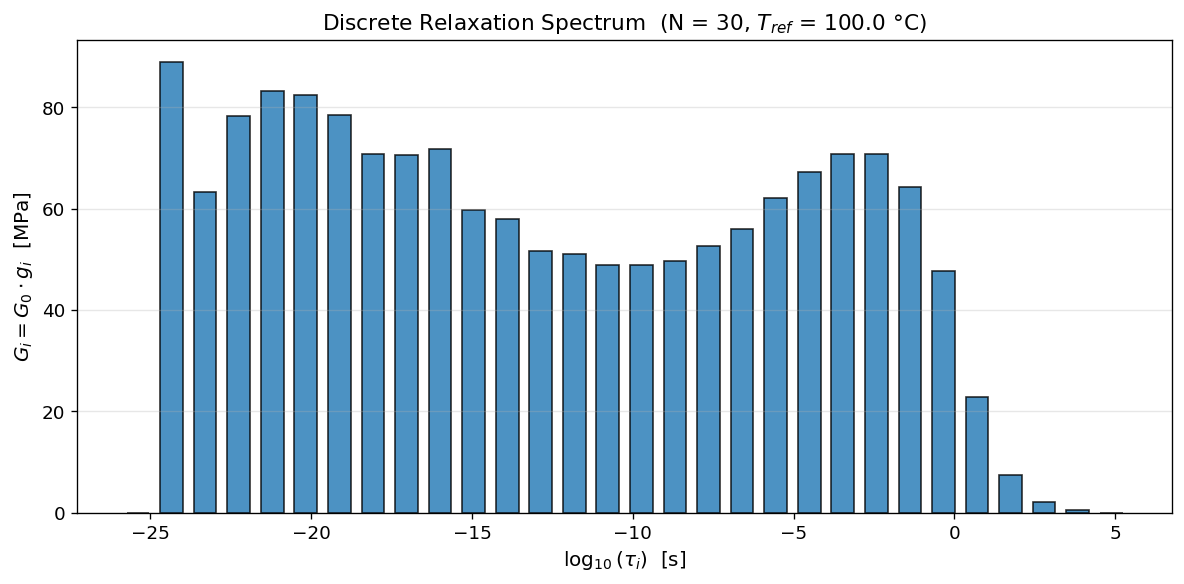

Relaxation times span: -25.4 to 4.9 (30 decades)

Top-5 dominant terms:
  i= 2: τ = 4.52e-25 s, g = 0.0560, G_i = 88.9 MPa
  i= 5: τ = 6.11e-22 s, g = 0.0524, G_i = 83.2 MPa
  i= 6: τ = 6.75e-21 s, g = 0.0519, G_i = 82.3 MPa
  i= 7: τ = 7.47e-20 s, g = 0.0494, G_i = 78.4 MPa
  i= 4: τ = 5.52e-23 s, g = 0.0494, G_i = 78.3 MPa


In [35]:
# Discrete relaxation spectrum
g_mc   = result_mc["g"]
tau_mc = result_mc["tau"]
G0_mc  = result_mc["G0"]

# Bar width = ~1 decade (matching collocation spacing)
bar_w = (np.log10(tau_mc.max()) - np.log10(tau_mc.min())) / len(tau_mc) * 0.7

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(np.log10(tau_mc), g_mc * G0_mc, width=bar_w,
              color="C0", edgecolor="black", alpha=0.8)
ax.set_xlabel("$\\log_{10}(\\tau_i)$  [s]")
ax.set_ylabel("$G_i = G_0 \\cdot g_i$  [MPa]")
ax.set_title(f"Discrete Relaxation Spectrum  (N = {N_BROAD}, $T_{{ref}}$ = {T_ref} °C)")
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(FIG_DIR / "relaxation_spectrum.png")
plt.show()

# Identify dominant terms (top-5 by weight)
top5 = np.argsort(g_mc)[-5:][::-1]
print(f"Relaxation times span: {np.log10(tau_mc.min()):.1f} to {np.log10(tau_mc.max()):.1f} "
      f"({np.log10(tau_mc.max()) - np.log10(tau_mc.min()):.0f} decades)")
print(f"\nTop-5 dominant terms:")
for idx in top5:
    print(f"  i={idx+1:2d}: τ = {tau_mc[idx]:.2e} s, g = {g_mc[idx]:.4f}, "
          f"G_i = {g_mc[idx]*G0_mc:.1f} MPa")

## 7 - Export Broadband Prony Parameters

Save broadband Prony parameters, WLF/Arrhenius coefficients, and master curve data.

In [ ]:
import json
from src.export import TABLE_DIR

# Broadband Prony CSV
csv_path = export_csv(result_mc["g"], result_mc["tau"], result_mc["G0"], result_mc["G_eq"],
                      filename="prony_params_broadband.csv")
print(f"Broadband Prony params -> {csv_path}")

# Broadband fit metrics
metrics_mc["T_ref_C"] = T_ref
metrics_mc["N_terms"] = N_BROAD
json_path = export_metrics_json(metrics_mc, filename="fit_metrics_broadband.json")
print(f"Broadband fit metrics  -> {json_path}")

# WLF & Arrhenius coefficients
tts_params = {
    "T_ref_C": T_ref,
    "WLF": {"C1": wlf_result["C1"], "C2": wlf_result["C2"],
             "residual_std": wlf_result["residual_std"]},
    "Arrhenius": {"Ea_over_R_K": arr_result["Ea_over_R_K"],
                   "Ea_kJ_mol": arr_result["Ea_kJ_mol"],
                   "residual_std": arr_result["residual_std"]},
}
tts_path = TABLE_DIR / "tts_shift_params.json"
with open(tts_path, "w") as f:
    json.dump(tts_params, f, indent=2)
print(f"TTS shift params       -> {tts_path}")

# Master curve data CSV
mc_export = mc[["omega_rad_s", "omega_reduced", "temp_C", "Gp_MPa", "Gpp_MPa", "tan_delta", "aT"]]
mc_csv_path = TABLE_DIR / "master_curve_data.csv"
mc_export.to_csv(mc_csv_path, index=False)
print(f"Master curve data      -> {mc_csv_path}")

# Abaqus snippet
print(f"\n--- Abaqus *VISCOELASTIC block (broadband, T_ref = {T_ref} C) ---")
print(export_abaqus_snippet(result_mc["g"], result_mc["tau"], result_mc["G0"], result_mc["G_eq"]))

Broadband Prony params → D:\Research\Resin-DMA2Prony\results\tables\prony_params_broadband.csv
Broadband fit metrics  → D:\Research\Resin-DMA2Prony\results\tables\fit_metrics_broadband.json
TTS shift params       → D:\Research\Resin-DMA2Prony\results\tables\tts_shift_params.json
Master curve data      → D:\Research\Resin-DMA2Prony\results\tables\master_curve_data.csv

── Abaqus *VISCOELASTIC block (broadband, T_ref = 100.0 °C) ──
*VISCOELASTIC, TIME=PRONY
  1.50385132e-21,  0.0,  4.08496732e-26
  5.60209336e-02,  0.0,  4.51679548e-25
  3.99344507e-02,  0.0,  4.99427285e-24
  4.93705430e-02,  0.0,  5.52222508e-23
  5.24474556e-02,  0.0,  6.10598796e-22
  5.18954043e-02,  0.0,  6.75146130e-21
  4.94349020e-02,  0.0,  7.46516862e-20
  4.46241364e-02,  0.0,  8.25432304e-19
  4.44395670e-02,  0.0,  9.12690018e-18
  4.52084285e-02,  0.0,  1.00917188e-16
  3.76755841e-02,  0.0,  1.11585298e-15
  3.65002351e-02,  0.0,  1.23381151e-14
  3.25192966e-02,  0.0,  1.36423962e-13
  3.22032593e-02,  0

## Summary

TTS master curve built from 26 temperature slices at T_ref = 100 C, spanning ~35 decades of reduced frequency. The Arrhenius model (Ea = 256.6 kJ/mol) fits the shift factors better than WLF for this wide temperature range - WLF converges toward the Arrhenius limit (C2 -> inf), which makes sense since WLF is really a near-Tg model.

Broadband Prony fit with N = 30 terms (collocation method) gives G' error of 3.2% and G'' error of 6.9% on the filtered data. The collocation approach - fixing tau at one per decade and only optimising weights - was essential to avoid the wild G'' oscillations from free-tau fitting.

The master curve G'' doesn't superpose perfectly across all temperatures, which is expected for thermosets with multiple relaxation mechanisms (thermorheological complexity).

## Encountered Issues & Learnings

**WLF singularity bug** - The WLF equation has a singularity at T = T_ref - C2. Initial guard used `np.sign(denom)` to avoid division by zero, but `np.sign(0) == 0` in numpy, so the guard itself produced zeros. Fixed by using `np.where(denom >= 0, 1.0, -1.0)` instead.

**WLF bounds problem** - First attempt had no lower bound on C2, so the optimizer sometimes placed the singularity right inside the data temperature range, causing the fit to blow up. Fixed by constraining C2 > (T_ref - T_fit_min + 2), keeping the singularity at least 2 C below the lowest data point.

**WLF vs Arrhenius** - For this material with a wide temperature range (-50 to 200 C), WLF converges to the Arrhenius limit (C2 -> infinity). This makes sense: WLF is physically a near-Tg model, and this data covers way more than the typical Tg +/- 50 C window. Added a `T_range` parameter to restrict WLF fitting to a physically meaningful window.

**Tau bounds too narrow for broadband** - The adaptive tau bounds from notebook 01 work fine for single-temperature data (~3 decades), but the master curve spans ~35 decades. Had to make the bounds follow the actual frequency range of the data being fitted.

**Log-space residuals for broadband data** - Relative residuals `(pred - data) / data` give too much weight to the high-value regions when data spans many decades. Switched to log-space residuals `log10(pred) - log10(data)` which weight all decades equally. Added auto-detection: if frequency spans > 4 decades, use log-space.

**G'' oscillations with free tau** - When tau positions are free parameters in broadband fitting, the optimizer can place multiple tau at similar values, causing wild oscillations in the G'' prediction. Solved by implementing a collocation method: fix tau at log-spaced positions (one per decade) and only optimise the weights g_i. Much more stable.

**Near-zero G'' wrecks the fit** - In the glassy plateau region, measured G'' values are near zero or even slightly negative (measurement noise). These dominate the log-space residuals. Fixed by filtering out data points with G'' below a noise floor threshold (0.5 MPa) before fitting.